In [1]:
print('Hi')

Hi


In [241]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [242]:
hps = pd.read_csv("Housing.csv")

In [243]:
hps.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [244]:
hps.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [245]:
def txt2bin(X):
    return X.map({'yes':1,'no':0}).astype("int64")

In [246]:
hps.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [247]:
varlist = ['mainroad','guestroom', 'basement', 'hotwaterheating', 'airconditioning','prefarea']
hps[varlist].info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   mainroad         545 non-null    str  
 1   guestroom        545 non-null    str  
 2   basement         545 non-null    str  
 3   hotwaterheating  545 non-null    str  
 4   airconditioning  545 non-null    str  
 5   prefarea         545 non-null    str  
dtypes: str(6)
memory usage: 25.7 KB


In [248]:
hps[varlist] = hps[varlist].apply(txt2bin)

In [249]:
hps.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    str  
dtypes: int64(12), str(1)
memory usage: 55.5 KB


In [250]:
status = pd.get_dummies(hps['furnishingstatus'])

In [251]:
status = pd.get_dummies(hps['furnishingstatus'],drop_first = True).astype("int64")
status

,semi-furnished,unfurnished
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0
...,...,...
540,0,1
541,1,0
542,0,1
543,0,0


In [252]:
status

,semi-furnished,unfurnished
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0
...,...,...
540,0,1
541,1,0
542,0,1
543,0,0


In [253]:
hps = pd.concat([hps,status],axis = True)

In [254]:
hps.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus', 'semi-furnished',
       'unfurnished'],
      dtype='str')

In [255]:
hps = hps.drop('furnishingstatus',axis = True)
hps.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'semi-furnished', 'unfurnished'],
      dtype='str')

In [256]:
hps.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862,0.416514,0.326606
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302,0.493434,0.469402
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000


In [257]:
# split the dataset as trian and test datasets
hps_train,hps_test = train_test_split(hps, train_size = 0.7, test_size = 0.3, random_state = 100)

In [258]:
hps_train.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'semi-furnished', 'unfurnished'],
      dtype='str')

In [259]:
numlist = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
hps_train[numlist].info()

<class 'pandas.DataFrame'>
Index: 381 entries, 359 to 520
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   price      381 non-null    int64
 1   area       381 non-null    int64
 2   bedrooms   381 non-null    int64
 3   bathrooms  381 non-null    int64
 4   stories    381 non-null    int64
 5   parking    381 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB


In [260]:
scaler = MinMaxScaler()
hps_train[numlist] = scaler.fit_transform(hps_train[numlist])
hps_train.info()

<class 'pandas.DataFrame'>
Index: 381 entries, 359 to 520
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            381 non-null    float64
 1   area             381 non-null    float64
 2   bedrooms         381 non-null    float64
 3   bathrooms        381 non-null    float64
 4   stories          381 non-null    float64
 5   mainroad         381 non-null    int64  
 6   guestroom        381 non-null    int64  
 7   basement         381 non-null    int64  
 8   hotwaterheating  381 non-null    int64  
 9   airconditioning  381 non-null    int64  
 10  parking          381 non-null    float64
 11  prefarea         381 non-null    int64  
 12  semi-furnished   381 non-null    int64  
 13  unfurnished      381 non-null    int64  
dtypes: float64(6), int64(8)
memory usage: 44.6 KB


In [261]:
hps_train.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
count,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000
mean,0.260333,0.288710,0.386352,0.136483,0.268591,0.855643,0.170604,0.351706,0.052493,0.299213,0.242345,0.233596,0.414698,0.325459
std,0.157607,0.181420,0.147336,0.237325,0.295001,0.351913,0.376657,0.478131,0.223313,0.458515,0.285933,0.423674,0.493318,0.469162
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.151515,0.155227,0.200000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.221212,0.234424,0.400000,0.000000,0.333333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.345455,0.398099,0.400000,0.500000,0.333333,1.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [262]:
y_train = hps_train.pop('price')
X_train = hps_train


In [263]:
X_train_sm = sm.add_constant(hps_train)
lm1 = sm.OLS(y_train,X_train).fit()
print(lm1.summary())

                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.915
Model:                            OLS   Adj. R-squared (uncentered):              0.912
Method:                 Least Squares   F-statistic:                              302.9
Date:                Sun, 25 Jan 2026   Prob (F-statistic):                   1.93e-187
Time:                        16:40:52   Log-Likelihood:                          381.32
No. Observations:                 381   AIC:                                     -736.6
Df Residuals:                     368   BIC:                                     -685.4
Df Model:                          13                                                  
Covariance Type:            nonrobust                                                  
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [264]:
vif = pd.DataFrame()
vif['Features'] = X_train.columns
vif["VIF"] =[variance_inflation_factor(X_train.values,i) for i in range(X_train.shape[1])]
vif["VIF"] = round(vif["VIF"],2)
vif = vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
1,bedrooms,7.33
4,mainroad,6.02
0,area,4.67
3,stories,2.70
11,semi-furnished,2.19
9,parking,2.12
6,basement,2.02
12,unfurnished,1.82
8,airconditioning,1.77
2,bathrooms,1.67


In [265]:
X_train = X_train.drop("bedrooms",axis = True)

In [266]:
X_train.columns

Index(['area', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement',
       'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'semi-furnished', 'unfurnished'],
      dtype='str')

In [267]:
X_train_sm2 = sm.add_constant(X_train)
lm2 = sm.OLS(y_train,X_train_sm2).fit()
print(lm2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     65.20
Date:                Sun, 25 Jan 2026   Prob (F-statistic):           2.35e-83
Time:                        16:40:52   Log-Likelihood:                 380.96
No. Observations:                 381   AIC:                            -735.9
Df Residuals:                     368   BIC:                            -684.7
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0351      0.017     

In [268]:
vif = pd.DataFrame()
vif["Features"] = X_train.columns
vif["VIF"] = [variance_inflation_factor(X_train.values,i) for i in range(X_train.shape[1])]
vif["VIF"] = round(vif["VIF"],2)
vif = vif.sort_values(by="VIF",ascending=False)
vif

,Features,VIF
3,mainroad,5.53
0,area,4.55
2,stories,2.24
8,parking,2.11
10,semi-furnished,1.97
5,basement,1.90
7,airconditioning,1.77
11,unfurnished,1.62
1,bathrooms,1.61
9,prefarea,1.51


In [269]:
X_train = X_train.drop("basement",axis = True)

In [270]:
X_train_sm3 = sm.add_constant(X_train)
lm3 = sm.OLS(y_train,X_train_sm3).fit()
print(lm3.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     69.98
Date:                Sun, 25 Jan 2026   Prob (F-statistic):           2.82e-83
Time:                        16:40:53   Log-Likelihood:                 378.52
No. Observations:                 381   AIC:                            -733.0
Df Residuals:                     369   BIC:                            -685.7
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0420      0.017     

In [271]:
vif = pd.DataFrame()
vif["Features"] = X_train.columns
vif["VIF"] = [variance_inflation_factor(X_train.values,i) for i in range(X_train.shape[1])]
vif["VIF"] = round(vif["VIF"],2)
vif = vif.sort_values(by="VIF",ascending=False)
vif

,Features,VIF
3,mainroad,5.38
0,area,4.55
2,stories,2.13
7,parking,2.11
9,semi-furnished,1.93
6,airconditioning,1.75
10,unfurnished,1.61
1,bathrooms,1.59
8,prefarea,1.47
4,guestroom,1.30


In [272]:
X_train = X_train.drop("semi-furnished",axis = True)

In [273]:
X_train_sm4 = sm.add_constant(X_train)
lm4 = sm.OLS(y_train,X_train_sm4).fit()
print(lm4.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                     77.18
Date:                Sun, 25 Jan 2026   Prob (F-statistic):           3.13e-84
Time:                        16:40:53   Log-Likelihood:                 378.51
No. Observations:                 381   AIC:                            -735.0
Df Residuals:                     370   BIC:                            -691.7
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0428      0.014     

In [274]:
vif = pd.DataFrame()
vif["Features"] = X_train.columns
vif["VIF"] = [variance_inflation_factor(X_train.values,i) for i in range(X_train.shape[1])]
vif["VIF"] = round(vif["VIF"],2)
vif = vif.sort_values(by="VIF",ascending=False)
vif

,Features,VIF
3,mainroad,4.55
0,area,4.54
2,stories,2.12
7,parking,2.10
6,airconditioning,1.75
1,bathrooms,1.58
8,prefarea,1.47
9,unfurnished,1.33
4,guestroom,1.30
5,hotwaterheating,1.12


In [275]:
y_predict =lm4.predict(X_train_sm4)

<Figure size 800x600 with 0 Axes>

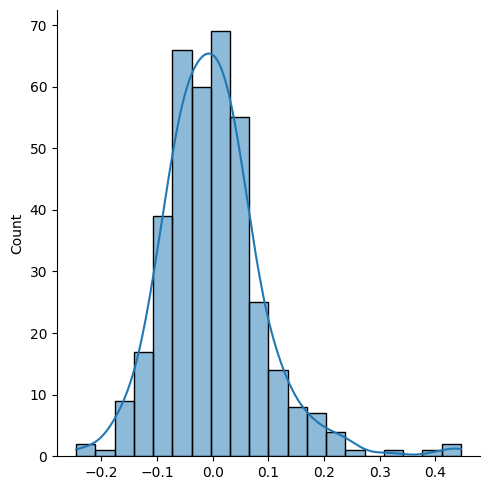

In [276]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.displot((y_train-y_predict),bins = 20,kde=True)
plt.show()

In [277]:
# Predictions on test data set
hps_test.columns


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'semi-furnished', 'unfurnished'],
      dtype='str')

In [278]:
numlists = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
hps_test[numlists].info()

<class 'pandas.DataFrame'>
Index: 164 entries, 265 to 50
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   price      164 non-null    int64
 1   area       164 non-null    int64
 2   bedrooms   164 non-null    int64
 3   bathrooms  164 non-null    int64
 4   stories    164 non-null    int64
 5   parking    164 non-null    int64
dtypes: int64(6)
memory usage: 9.0 KB


In [279]:
hps_test[numlists] = scaler.transform(hps_test[numlists])
hps_test.info()


<class 'pandas.DataFrame'>
Index: 164 entries, 265 to 50
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            164 non-null    float64
 1   area             164 non-null    float64
 2   bedrooms         164 non-null    float64
 3   bathrooms        164 non-null    float64
 4   stories          164 non-null    float64
 5   mainroad         164 non-null    int64  
 6   guestroom        164 non-null    int64  
 7   basement         164 non-null    int64  
 8   hotwaterheating  164 non-null    int64  
 9   airconditioning  164 non-null    int64  
 10  parking          164 non-null    float64
 11  prefarea         164 non-null    int64  
 12  semi-furnished   164 non-null    int64  
 13  unfurnished      164 non-null    int64  
dtypes: float64(6), int64(8)
memory usage: 19.2 KB


In [280]:
y_test = hps_test.pop('price')
X_test = hps_test

In [281]:
X_test_sm = sm.add_constant(X_test)

In [282]:
X_test_sm = X_test_sm.drop(["bedrooms","basement","semi-furnished"],axis=True)

In [284]:
y_predict_test = lm4.predict(X_test_sm)

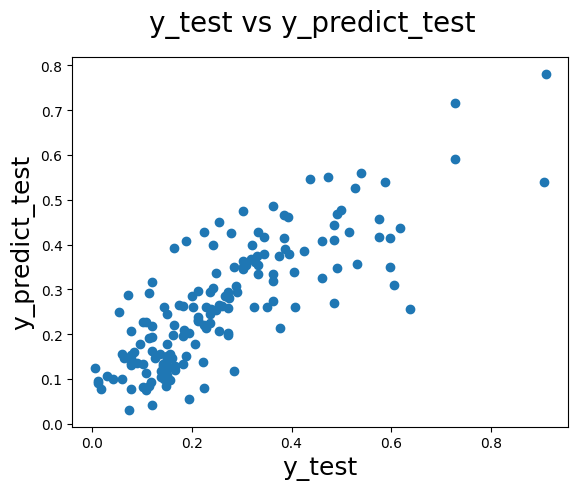

In [290]:
fig = plt.figure()
plt.scatter(y_test,y_predict_test)
fig.suptitle('y_test vs y_predict_test',fontsize=20)
plt.xlabel("y_test",fontsize=18)
plt.ylabel("y_predict_test",fontsize=18)
plt.show()